### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

## Problems

### Use the prompts below to get started with your data analysis.  

### 1. Read in the `coupons.csv` file.




In [210]:
data = pd.read_csv('data/coupons.csv')

In [211]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


### 2. Investigate the dataset for missing or problematic data.

We can first look at the shape of the dataset and also more rows to get a better sense of how the database looks like and what problematic entries exist.

In [212]:
data.shape

(12684, 26)

In [213]:
data.head(50)

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
5,No Urgent Place,Friend(s),Sunny,80,6PM,Restaurant(<20),2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
6,No Urgent Place,Friend(s),Sunny,55,2PM,Carry out & Take away,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
7,No Urgent Place,Kid(s),Sunny,80,10AM,Restaurant(<20),2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
8,No Urgent Place,Kid(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
9,No Urgent Place,Kid(s),Sunny,80,10AM,Bar,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


The very first problematic feature seems to be missing values. This feature can be investigated by looking at the pattern of missing values across columns, i.e., how many missing entries exist per column.

In [214]:
data.isnull().sum()

destination                 0
passanger                   0
weather                     0
temperature                 0
time                        0
coupon                      0
expiration                  0
gender                      0
age                         0
maritalStatus               0
has_children                0
education                   0
occupation                  0
income                      0
car                     12576
Bar                       107
CoffeeHouse               217
CarryAway                 151
RestaurantLessThan20      130
Restaurant20To50          189
toCoupon_GEQ5min            0
toCoupon_GEQ15min           0
toCoupon_GEQ25min           0
direction_same              0
direction_opp               0
Y                           0
dtype: int64

We can also look at the percentage of missing entries.

In [215]:
(data.isnull().sum() / len(data)) * 100

destination              0.000000
passanger                0.000000
weather                  0.000000
temperature              0.000000
time                     0.000000
coupon                   0.000000
expiration               0.000000
gender                   0.000000
age                      0.000000
maritalStatus            0.000000
has_children             0.000000
education                0.000000
occupation               0.000000
income                   0.000000
car                     99.148534
Bar                      0.843582
CoffeeHouse              1.710817
CarryAway                1.190476
RestaurantLessThan20     1.024913
Restaurant20To50         1.490066
toCoupon_GEQ5min         0.000000
toCoupon_GEQ15min        0.000000
toCoupon_GEQ25min        0.000000
direction_same           0.000000
direction_opp            0.000000
Y                        0.000000
dtype: float64

Next, we check the entries to make sure the data is clean. For example, from the data.head() command above, 4~8 in the RestaurantLessThan20 column might be problematic, although if it appears like that every single time, we will be able to handle it. So, we can check how various entries look like by using the command unique.

In [216]:
for col in data.columns:
    print(col, data[col].unique())

destination ['No Urgent Place' 'Home' 'Work']
passanger ['Alone' 'Friend(s)' 'Kid(s)' 'Partner']
weather ['Sunny' 'Rainy' 'Snowy']
temperature [55 80 30]
time ['2PM' '10AM' '6PM' '7AM' '10PM']
coupon ['Restaurant(<20)' 'Coffee House' 'Carry out & Take away' 'Bar'
 'Restaurant(20-50)']
expiration ['1d' '2h']
gender ['Female' 'Male']
age ['21' '46' '26' '31' '41' '50plus' '36' 'below21']
maritalStatus ['Unmarried partner' 'Single' 'Married partner' 'Divorced' 'Widowed']
has_children [1 0]
education ['Some college - no degree' 'Bachelors degree' 'Associates degree'
 'High School Graduate' 'Graduate degree (Masters or Doctorate)'
 'Some High School']
occupation ['Unemployed' 'Architecture & Engineering' 'Student'
 'Education&Training&Library' 'Healthcare Support'
 'Healthcare Practitioners & Technical' 'Sales & Related' 'Management'
 'Arts Design Entertainment Sports & Media' 'Computer & Mathematical'
 'Life Physical Social Science' 'Personal Care & Service'
 'Community & Social Services' 

From the output above, we can safely choose not to alter any entry and leave the ones not removed intact. There is a possibility that we need to convert some strings (like '21' in the age column) to numbers. We can do so later if needed.

We should also check for duplicate rows.

In [219]:
data.duplicated().sum()

np.int64(74)

The output above shows there are 74 duplicate rows, which need to be removed.

### 3. Decide what to do about your missing data—drop, replace, other...

The following manipiulations should be done at the beginning. As said earlier, other manipulations, like converting strings to numerics may be performed later if necessary.

**1-** It seems we can safely drop the car column altogether. \
**2-** We can also remove the rows where the corresponding values in the Bar, CoffeeHouse, CarryAway, RestaurantLessThan20, and Restaurant20To50 columns are missing, because these entries constitute a small fraction (< 1.7%) of respondents. Therefore, removal of these entries should not impact our statistical inference.\
**3**- Remove duplicate rows.

In [221]:
# New DatFrame for cleaned data. 
# 1- Remove the 'car' column.
data_clean = data.drop(columns=['car'])

In [223]:
# Check 
data_clean.columns

Index(['destination', 'passanger', 'weather', 'temperature', 'time', 'coupon',
       'expiration', 'gender', 'age', 'maritalStatus', 'has_children',
       'education', 'occupation', 'income', 'Bar', 'CoffeeHouse', 'CarryAway',
       'RestaurantLessThan20', 'Restaurant20To50', 'toCoupon_GEQ5min',
       'toCoupon_GEQ15min', 'toCoupon_GEQ25min', 'direction_same',
       'direction_opp', 'Y'],
      dtype='object')

In [225]:
# 2- Remove the rows where the corresponding values in the Bar, CoffeeHouse, CarryAway, RestaurantLessThan20, and Restaurant20To50 columns are missing.
data_clean = data_clean.dropna(subset=[
    'Bar',
    'CoffeeHouse',
    'CarryAway',
    'RestaurantLessThan20',
    'Restaurant20To50'
])

In [226]:
# Remove duplicate rows.
data_clean = data_clean.drop_duplicates()

In [228]:
# Check
data_clean.duplicated().sum()

np.int64(0)

### 4. What proportion of the total observations chose to accept the coupon?


We first create a DataFrame that is a copy of the _original dataset_ with duplicate rows removed No other entry has been removed in this copy.

In [113]:
data_temp = data.drop_duplicates()

In [240]:
# Check acceptance percentage 
print(f"Not Accepted: {data_temp['Y'].value_counts(normalize=True)[0]:.2%}")
print(f"Accepted: {data_temp['Y'].value_counts(normalize=True)[1]:.2%}")



Not Accepted: 43.24%
Accepted: 56.76%


The output above shows 56.8% of the respondents accepted the coupon and 43.2% did not. However, these are based on the original dataset. Recalculating the numbers based on the cleaned version of the data set will yield

In [241]:
print(f"Not Accepted: {data_clean['Y'].value_counts(normalize=True)[0]:.2%}")
print(f"Accepted: {data_clean['Y'].value_counts(normalize=True)[1]:.2%}")

Not Accepted: 43.16%
Accepted: 56.84%


This shows the same numbers (with only 0.08% difference), confirming that the removed rows (due to NaN values) would not change our statistical inference.

### 5. Use a bar plot to visualize the `coupon` column.

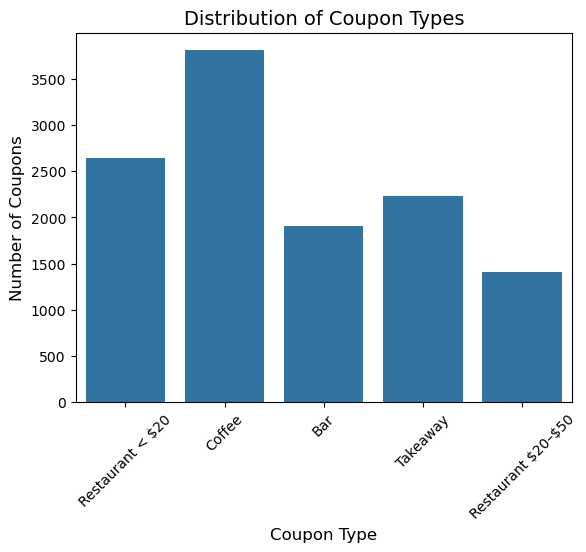

In [242]:
# Replace the entries in the coupon column for cleaner plot labels.
data_clean['coupon'] = data_clean['coupon'].replace({
    'Coffee House': 'Coffee',
    'Carry out & Take away': 'Takeaway',
    'Restaurant(<20)': 'Restaurant < \$20',
    'Restaurant(20-50)': 'Restaurant \$20–\$50'
})
sns.countplot(x='coupon', data=data_clean)
plt.xticks(rotation=45)
plt.xlabel('Coupon Type', fontsize=12)
plt.ylabel('Number of Coupons', fontsize=12)
plt.title('Distribution of Coupon Types', fontsize=14)
plt.show()

The plot above shows that coffee house is the most frequently offered coupon and more expensive restaurants are offered least often. This distribution can help us understand and interpret acceptance rates across different types of coupons. (**Note**: We changed the name of the coupon types in the DataFrame for cleaner plots.)

### 6. Use a histogram to visualize the temperature column.

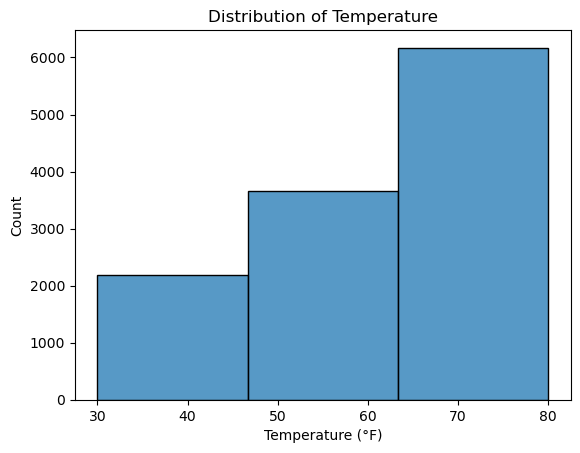

In [246]:
sns.histplot(data=data_clean, x='temperature', bins=3)

plt.xlabel('Temperature (°F)')
plt.ylabel('Count')
plt.title('Distribution of Temperature')

plt.show()

The temperature takes only 3 discrete values (30°F, 55°F, and 80°F), which we consider adequate for interpretting the decision-making patterns that are based on temperature, because the values cover very cold, moderate, and warm temperatures. Having a hot temperature, like 100°F, would make temperature-based inferences more accurate. We could remove bins=3 and get thinner bars as follows. 

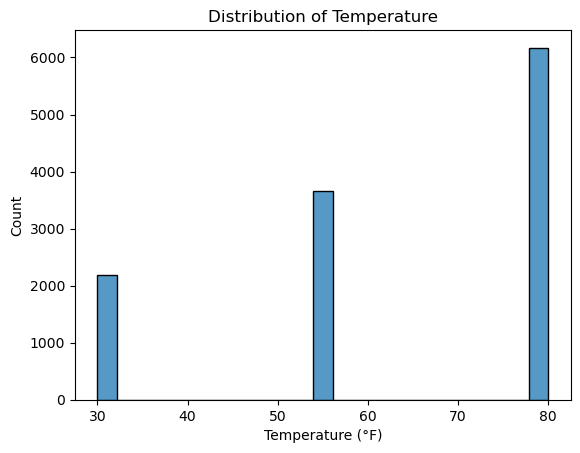

In [247]:
sns.histplot(data=data_clean, x='temperature')

plt.xlabel('Temperature (°F)')
plt.ylabel('Count')
plt.title('Distribution of Temperature')

plt.show()

We can also use countplot, **which we like the most**, because this way, the temperature values would be clear from the plot.

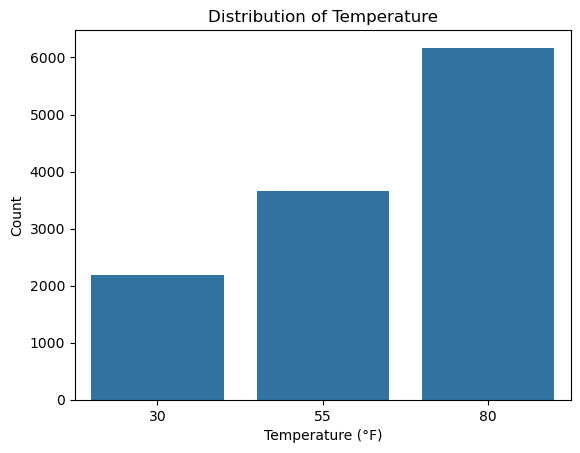

In [124]:
sns.countplot(x='temperature', data=data_clean)
plt.xlabel('Temperature (°F)')
plt.ylabel('Count')
plt.title('Distribution of Temperature')

plt.show()

Color-coding the count plot based on the Y column shows how the temperature can impact the decision, although the temperature is clearly not the only factor here.

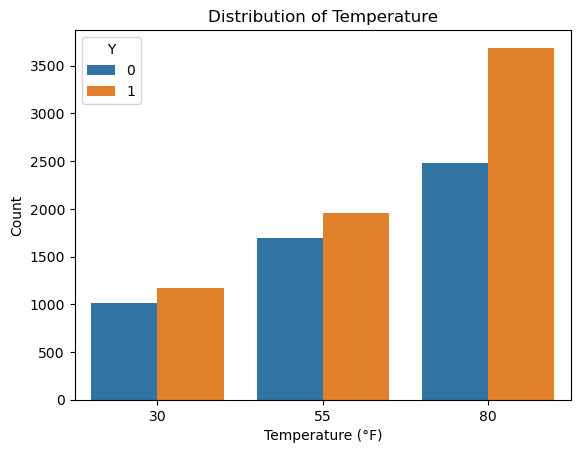

In [125]:
sns.countplot(x='temperature', data=data_clean, hue='Y')
plt.xlabel('Temperature (°F)')
plt.ylabel('Count')
plt.title('Distribution of Temperature')

plt.show()

The plot above shows that the gap between Yes and No widens as the weather gets warmer, meaning more percentage of people tend to accept the coupon at a warm temperature. This is obviously a rudimentary observation, not quantified.

### **Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

**1. Create a new `DataFrame` that contains just the bar coupons.**


In [248]:
bar_data = data_clean[data_clean['coupon'] == 'Bar']

**2. What proportion of bar coupons were accepted?**


In [249]:
# Combine the print command and portion calculation.
print(f"Not Accepted: {bar_data['Y'].value_counts(normalize=True)[0]:.1%}")
print(f"Accepted: {bar_data['Y'].value_counts(normalize=True)[1]:.1%}")

Not Accepted: 58.8%
Accepted: 41.2%


This shows that 41.2% of bar coupons were accepted. 

**3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.**


The values in the Bar column that qualify are 'never', 'less1', and '1~3'.

In [251]:
# Create two DataFrames based on the entries in the Bar columns.
bar_lte3 = bar_data[bar_data['Bar'].isin(['never', 'less1', '1~3'])]
bar_gt3 = bar_data[bar_data['Bar'].isin(['4~8', 'gt8'])]

# Calculate the mean values of the Y column in each new DataFrame, which is equivalent to the acceptance rate.
bar_lte3_rate = bar_lte3['Y'].mean()
bar_gt3_rate = bar_gt3['Y'].mean()

print(f"3 or Fewer Times a Month: {bar_lte3_rate:.1%}")
print(f"More: {bar_gt3_rate:.1%}")

3 or Fewer Times a Month: 37.2%
More: 76.2%


The numbers above show that 37.2% of those who go to a bar 3 times or less per month accepted the bar coupon while 76.2% of those who go to a bar more than 3 times a month accepted the bar coupon. In other words, drivers who visit bars more than three times a month have a significantly higher coupon acceptance rate compared to those who visit less frequently. This shows the impact of prior behavior in accepting a coupon. (**Note**: Calculating the mean value of a series of 1 and 0 would yield the same result as counting the 1s.)

We can also visualize the above rates as follows.

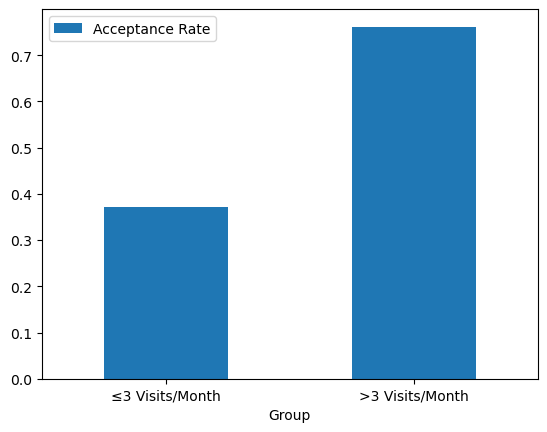

In [252]:
# Create a new DataFrame with two columns (for bar visit rate and acceptance rate) 
rates = pd.DataFrame({
    'Group': ['≤3 Visits/Month', '>3 Visits/Month'],
    'Acceptance Rate': [bar_lte3_rate, bar_gt3_rate]
})

rates.plot(kind='bar', x='Group', y='Acceptance Rate', legend=True)
plt.xticks(rotation=0)
plt.show()

**4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?**


In [253]:
# Define Group 1 based on the target group
group1 = bar_data[
    (bar_data['Bar'].isin(['1~3', '4~8', 'gt8'])) &
    (~bar_data['age'].isin(['below21', '21']))
]
# Drop others and group them into Group 2
group2 = bar_data.drop(group1.index)

rate1 = group1['Y'].mean()
rate2 = group2['Y'].mean()

print(f"Target Group: {rate1:.1%}")
print(f"Others: {rate2:.1%}")

Target Group: 69.0%
Others: 33.7%


This shows a significant difference. The drivers who go to a bar more than once a month and are over 25 are _significantly more likely_ to accept the bar coupon than those who do not fit in that description. (**Note**: From this dataset, it is not possible to isolate those who go to a bar 2 to 3 times a month from those who go to a bar only once a month. All are descrtibed as 1~3.) 

**5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.**


In [254]:
# Define Group 1 based on the target group
group1 = bar_data[
    (bar_data['Bar'].isin(['1~3', '4~8', 'gt8'])) &
    (~bar_data['passanger'].isin(['Kids(s)'])) &
    (~bar_data['occupation'].isin(['Farming Fishing & Forestry']))
]
# Drop others and group them into Group 2
group2 = bar_data.drop(group1.index)

rate1 = group1['Y'].mean()
rate2 = group2['Y'].mean()

print(f"Target Group: {rate1:.1%}")
print(f"Others: {rate2:.1%}")

Target Group: 68.5%
Others: 29.5%


Again, this shows a significant difference. The drivers who go to bars more than once a month, had passengers that were not a kid, and had occupations other than farming, fishing, or forestry are significantly more likely to accept a bar coupon than those who do not fit in that description.

6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [255]:
# Define Crtiterion 1
crit1 = (
    bar_data['Bar'].isin(['1~3', '4~8', 'gt8']) &
    (~bar_data['passanger'].isin(['Kids(s)'])) &
    (~bar_data['maritalStatus'].isin(['Widowed']))
)

# Define Criterion 2
crit2 = (
    bar_data['Bar'].isin(['1~3', '4~8', 'gt8']) &
    (bar_data['age'].isin(['below21' , '21', '26']))
)

# Define Criterion 3
crit3 = (
    bar_data['RestaurantLessThan20'].isin(['4~8', 'gt8']) &
    bar_data['income'].isin([
        'Less than $12500',
        '$12500 - $24999',
        '$25000 - $37499',
        '$37500 - $49999'
    ])
)

# Define the target group  
target_group = bar_data[crit1 | crit2| crit3]

# Drop all others and group them into 'others'
others = bar_data.drop(target_group.index)

# Calculate ascceptance rates
rate_target = target_group['Y'].mean()
rate_others = others['Y'].mean()

print(f"Target Group: {rate_target:.1%}")
print(f"Others: {rate_others:.1%}")

Target Group: 57.3%
Others: 30.1%


These numbers show that the drivers in the target group are almost twice more likely to accept the bar coupons than the drivers who are not in the target group.

**7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?**

One immediate conclusion is that prior behavior is perhaps the most important inidicator. Drivers who go to bars more frequently than others are more likely to accept a bar coupon, regardless of other filtering crieteria.

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

### **Investigating the Carryout & Takeaway Coupons**

We explore the 'Carry out & Take away' coupon group and find some characteristics of the drivers who accepted the coupon.

In [256]:
# Create a DataFrame including only rows corresponding to the respondents who received the Carry out & Take away coupon.
# Remember we had changed the name of the entries of the coupon column before.
carry_data = data_clean[data_clean['coupon'] == 'Takeaway']


Now we calculate the acceptance percentage within this group.

In [258]:
print(f"Not Accepted: {carry_data['Y'].value_counts(normalize=True)[0]:.1%}")
print(f"Accepted: {carry_data['Y'].value_counts(normalize=True)[1]:.1%}")

Not Accepted: 26.4%
Accepted: 73.6%


This show **73.6%** of the recipients accepted the coupon. 

We now compare acceptance rate by passenger type.

In [261]:
carry_passenger_rates = carry_data.groupby('passanger')['Y'].mean()*100 #Note: The column is named 'passanger' in the database!
carry_passenger_rates

passanger
Alone        72.937548
Friend(s)    75.886525
Kid(s)       69.503546
Partner      71.111111
Name: Y, dtype: float64

We can also visualize the above rates.

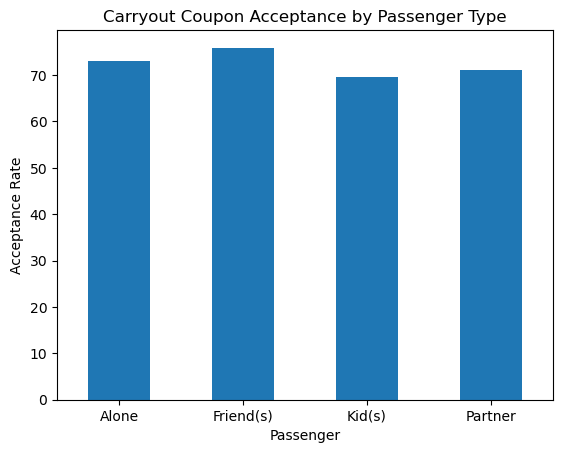

In [198]:
carry_passenger_rates.plot(kind='bar')

plt.xticks(rotation=0)
plt.xlabel('Passenger')
plt.ylabel('Acceptance Rate')
plt.title('Carryout Coupon Acceptance by Passenger Type')

plt.show()

This shows, regardless of the passenger type, a strong majority of the drivers accepted the takeaway coupon. However, _no passenger type is significantly more likely to impact the acceptance rate_, although driving with friends makes it slightly more likely for the coupon to be accepted.

Now, we can compare the acceptance rate between those who order takeaway 3 or fewer times a month to the acceptance rate between those who frequently order takeaway (more than 3 times a month).

In [262]:
# Define two DataFrames based on the entries in the CarryAway column.
carry_lte3 = carry_data[carry_data['CarryAway'].isin(['never', 'less1', '1~3'])]
carry_gt3 = carry_data[carry_data['CarryAway'].isin(['4~8', 'gt8'])]

# Calculate the acceptance rate among the two groups
carry_lte3_rate = bar_lte3['Y'].mean()
carry_gt3_rate = bar_gt3['Y'].mean()

print(f"3 or Fewer Times a Month: {carry_lte3_rate:.1%}")
print(f"More: {carry_gt3_rate:.1%}")

3 or Fewer Times a Month: 37.2%
More: 76.2%


We plot these rates using a bar plot.

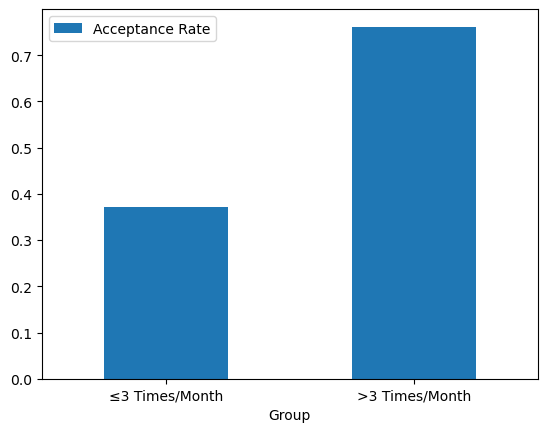

In [264]:
# Define a DataFrame based on the two groups above and the acceptance rates
carry_rates = pd.DataFrame({
    'Group': ['≤3 Times/Month', '>3 Times/Month'],
    'Acceptance Rate': [carry_lte3_rate, carry_gt3_rate]
})

carry_rates.plot(kind='bar', x='Group', y='Acceptance Rate', legend=True)
plt.xticks(rotation=0)
plt.show()

This shows prior behavior can have a strong impact on the possibility of acceptance.

Now, we want to explore how a combination of factors (passenger, time of the day, and destination) can impact the decision to accept the takeaway coupon.

In [205]:
# Group the DataFrame by passenger, time, and destination, then calculate the mean of the Y column (i.e., acceptance rate)
combo_rates = carry_data.groupby(
    ['passanger', 'time', 'destination']
)['Y'].mean().reset_index()
combo_rates

,passanger,time,destination,Y
0,Alone,10AM,No Urgent Place,0.916667
1,Alone,10PM,Home,0.802817
2,Alone,2PM,No Urgent Place,0.771429
3,Alone,6PM,Home,0.818462
4,Alone,7AM,Work,0.652616
5,Friend(s),10AM,No Urgent Place,0.671554
6,Friend(s),10PM,No Urgent Place,0.784431
7,Friend(s),2PM,No Urgent Place,0.885057
8,Friend(s),6PM,No Urgent Place,0.913043
9,Kid(s),10AM,No Urgent Place,0.734940


Visual inspection of the DataFrame above may not reveal a pattern easily. We want to create a heatmap to better understand a pattern of acceptance.

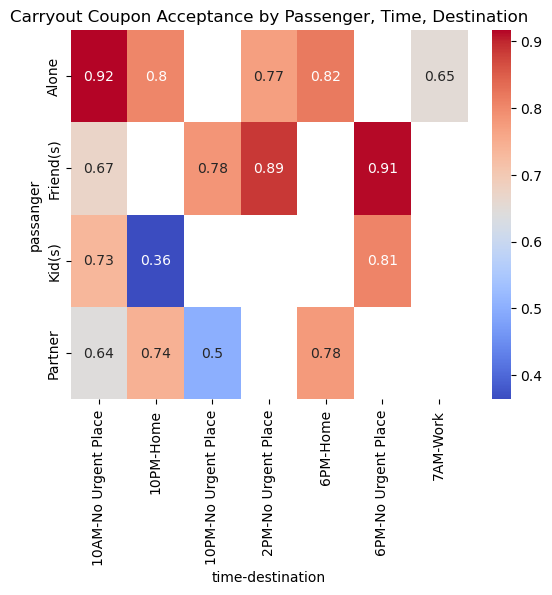

In [209]:
pivot = carry_data.pivot_table(
    values='Y',
    index='passanger',
    columns=['time', 'destination'],
    aggfunc='mean'
)

sns.heatmap(pivot,annot=True,cmap='coolwarm')

plt.title('Carryout Coupon Acceptance by Passenger, Time, Destination')
plt.show()

The heatmap clearly implies that, overall, _people who are drving alone or with friends are more likely to accept the takeaway coupon._